# KON-NECT — Deep Learning Reference Model

This notebook is the **reference implementation** for the machine-learning pipeline that will power KON-NECT at scale.  
It mirrors what the current Node.js/MongoDB backend already does, but expresses it through a proper ML stack (Jaccard Similarity + Graph Neural Network) so it can be dropped in when the server is upgraded.

---

### What the current app does (implemented in `server/index.js`)

| Feature | Current implementation | This notebook |
|---|---|---|
| Geo-radius filter | MongoDB `$geoNear maxDistance: 20 000 m` | Haversine / OSRM ≤ 20 km check |
| Interest matching | Set intersection → count shared tags | **Jaccard Similarity** coefficient |
| User ranking | Sorted by `sharedInterests.length` descending | Jaccard score descending |
| Clustering | K-means on `[lon, lat]` with primary interest label | **Graph Neural Network (GNN)** embedding + community detection |
| Distance display | OSRM road distance via `/route/v1/driving` | Same OSRM call with geodesic fallback |

---

## 1. Dependencies & Imports

In [1]:
# Standard / scientific
import pandas as pd
import numpy as np
import random
import requests
import math
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# PyTorch — GNN layers
import torch
import torch.nn as nn
import torch.nn.functional as F

print("All imports OK.")

All imports OK.


## 2. Configuration

These constants mirror the values hard-coded in `server/index.js`.

In [2]:
# ── Geo radius (matches MongoDB $geoNear maxDistance in the app) ──────────────
RADIUS_KM = 20.0          # 20 km — only users within this radius are considered

# ── Interest pool (12 standard categories in the app + free-text custom tags) ─
INTERESTS_POOL = [
    "Sports", "Music", "Gaming", "Gym", "Movies", "Coding",
    "Travel", "Art", "Food", "Reading", "Photography", "Dance"
]

# ── GNN hyperparameters ───────────────────────────────────────────────────────
GNN_HIDDEN      = 32    # hidden layer width
GNN_EMBED_DIM   = 16    # final embedding dimension per user node
N_USERS         = 20    # synthetic user count for the demo

# ── OSRM public API (same endpoint the app uses) ─────────────────────────────
OSRM_BASE = "http://router.project-osrm.org/route/v1/driving"

print(f"Radius: {RADIUS_KM} km | Pool: {len(INTERESTS_POOL)} interests | Users: {N_USERS}")

Radius: 20.0 km | Pool: 12 interests | Users: 20


## 3. Synthetic User Generation

In production these records come from the MongoDB `users` collection.  
Here we generate realistic fake users seeded around a central coordinate.

In [3]:
def generate_users(n: int, center_lat: float, center_lon: float, spread_km: float = 25.0):
    """
    Generate `n` synthetic users scattered within `spread_km` of the centre.
    Each user has 1-4 interests drawn randomly from INTERESTS_POOL.
    """
    users = []
    # 1 degree latitude ≈ 111 km
    spread_deg = spread_km / 111.0

    for i in range(n):
        lat = center_lat + random.uniform(-spread_deg, spread_deg)
        lon = center_lon + random.uniform(-spread_deg, spread_deg)
        k   = random.randint(1, 4)
        interests = random.sample(INTERESTS_POOL, k)
        users.append({
            "id":        f"user_{i+1:03d}",
            "lat":       round(lat, 4),
            "lon":       round(lon, 4),
            "interests": interests,
            # Primary interest = first in list (used for cluster labelling)
            "primary":   interests[0],
        })

    return users


# Seed: Vijayawada, Andhra Pradesh
CENTER_LAT, CENTER_LON = 16.5062, 80.6480

random.seed(42)
users = generate_users(N_USERS, CENTER_LAT, CENTER_LON)

df_users = pd.DataFrame(users)
print(f"Generated {len(df_users)} users\n")
print(df_users[["id", "lat", "lon", "primary", "interests"]].head(10).to_string(index=False))

Generated 20 users

      id     lat     lon primary                   interests
user_001 16.5690 80.4340     Gym        [Gym, Dance, Gaming]
user_002 16.6127 80.7276 Reading                   [Reading]
user_003 16.4710 80.4362     Gym                 [Gym, Food]
user_004 16.5522 80.6756     Gym [Gym, Art, Reading, Movies]
user_005 16.6456 80.4257   Dance             [Dance, Travel]
user_006 16.4342 80.4928   Music      [Music, Dance, Travel]
user_007 16.3245 80.8045  Sports         [Sports, Art, Food]
user_008 16.3372 80.8382    Food                      [Food]
user_009 16.4130 80.7059 Reading       [Reading, Gym, Music]
user_010 16.3016 80.5254   Music         [Music, Gym, Dance]


## 4. Geo-Radius Filter (20 km)

Mirrors the MongoDB `$geoNear` + `maxDistance: 20000` pipeline in `server/index.js`.  
Only users within the radius of a given query user are candidates for matching.

In [4]:
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """
    Fast great-circle distance in km (matches the `getDistance` helper in
    `client/src/components/Map.jsx` which uses OpenLayers `getDistance`).
    """
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(dlon / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def get_nearby_users(query_user: dict, all_users: list, radius_km: float = RADIUS_KM):
    """
    Return users within `radius_km` of `query_user`, excluding themselves.
    Equivalent to the $geoNear stage in the /api/users/nearby endpoint.
    """
    nearby = []
    for u in all_users:
        if u["id"] == query_user["id"]:
            continue
        dist = haversine_km(query_user["lat"], query_user["lon"], u["lat"], u["lon"])
        if dist <= radius_km:
            nearby.append({**u, "distance_km": round(dist, 3)})
    return nearby


# Demo: find everyone near user_001
query = users[0]
nearby = get_nearby_users(query, users)
print(f"Query user  : {query['id']} @ ({query['lat']}, {query['lon']})")
print(f"Nearby count: {len(nearby)} / {N_USERS - 1} within {RADIUS_KM} km\n")
for u in nearby[:5]:
    print(f"  {u['id']}  {u['distance_km']:>6.2f} km   interests: {u['interests']}")

Query user  : user_001 @ (16.569, 80.434)
Nearby count: 5 / 19 within 20.0 km

  user_003   10.90 km   interests: ['Gym', 'Food']
  user_005    8.56 km   interests: ['Dance', 'Travel']
  user_006   16.25 km   interests: ['Music', 'Dance', 'Travel']
  user_016   12.10 km   interests: ['Gym', 'Photography', 'Art']
  user_019   18.73 km   interests: ['Music', 'Sports', 'Dance', 'Gaming']


## 5. Interest Matching — Jaccard Similarity

### What the app currently does
```js
// server/index.js  — /api/users/nearby
const sharedInterests = nearbyUser.interests.filter(i =>
    currentUser.interests.includes(i)
);
// sorted by sharedInterests.length descending
```
This is equivalent to the **Jaccard numerator** (|A ∩ B|) without normalising by the union.

### Upgraded: Jaccard Similarity Coefficient
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

This gives a score in **[0, 1]** that is fair regardless of how many total interests each user has.  
A score of `1.0` means identical interest sets; `0.0` means no overlap at all.

In [5]:
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """
    Jaccard Similarity: |A ∩ B| / |A ∪ B|
    Returns 0.0 when both sets are empty.
    """
    intersection = len(set_a & set_b)
    union        = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0


def rank_nearby_by_interest(query_user: dict, nearby_users: list) -> list:
    """
    Score each nearby user by Jaccard similarity with the query user,
    then sort descending — highest match first.

    This replaces the simple `sharedInterests.length` sort in the app.
    """
    q_set = set(query_user["interests"])
    ranked = []
    for u in nearby_users:
        u_set  = set(u["interests"])
        score  = jaccard_similarity(q_set, u_set)
        shared = list(q_set & u_set)
        ranked.append({**u, "jaccard": round(score, 4), "shared": shared})

    return sorted(ranked, key=lambda x: x["jaccard"], reverse=True)


# ── Demo ─────────────────────────────────────────────────────────────────────
ranked_nearby = rank_nearby_by_interest(query, nearby)

print(f"Query user  : {query['id']}")
print(f"Interests   : {query['interests']}\n")
print(f"{'Rank':<6} {'User':<12} {'Dist km':<10} {'Jaccard':<10} {'Shared interests'}")
print("-" * 70)
for rank, u in enumerate(ranked_nearby, 1):
    shared_str = ", ".join(u["shared"]) if u["shared"] else "—"
    print(f"{rank:<6} {u['id']:<12} {u['distance_km']:<10} {u['jaccard']:<10} {shared_str}")

Query user  : user_001
Interests   : ['Gym', 'Dance', 'Gaming']

Rank   User         Dist km    Jaccard    Shared interests
----------------------------------------------------------------------
1      user_019     18.733     0.4        Gaming, Dance
2      user_003     10.9       0.25       Gym
3      user_005     8.563      0.25       Dance
4      user_006     16.247     0.2        Dance
5      user_016     12.095     0.2        Gym


## 6. Full Jaccard Similarity Matrix

Compute pairwise Jaccard scores across **all** users.  
This matrix becomes the weighted adjacency matrix fed into the GNN in the next section.

In [6]:
def build_jaccard_matrix(users: list) -> torch.Tensor:
    """
    Build an N×N Jaccard similarity matrix.
    Entry [i,j] = Jaccard(user_i.interests, user_j.interests).
    Diagonal is 1.0 (self-similarity).
    """
    n = len(users)
    mat = torch.zeros((n, n), dtype=torch.float)
    for i in range(n):
        for j in range(n):
            si = set(users[i]["interests"])
            sj = set(users[j]["interests"])
            mat[i, j] = jaccard_similarity(si, sj)
    return mat


def build_geo_mask(users: list, radius_km: float = RADIUS_KM) -> torch.Tensor:
    """
    Binary mask: 1 if two users are within `radius_km`, else 0.
    Mirrors the 20 km geo-filter in $geoNear.
    Self-connections are 1.
    """
    n = len(users)
    mask = torch.zeros((n, n), dtype=torch.float)
    for i in range(n):
        for j in range(n):
            dist = haversine_km(
                users[i]["lat"], users[i]["lon"],
                users[j]["lat"], users[j]["lon"]
            )
            if dist <= radius_km:
                mask[i, j] = 1.0
    return mask


jaccard_mat = build_jaccard_matrix(users)
geo_mask    = build_geo_mask(users)

# Weighted adjacency = Jaccard score only where users are within geo-radius
adj = jaccard_mat * geo_mask

print(f"Jaccard matrix shape : {jaccard_mat.shape}")
print(f"Geo mask — edges     : {int(geo_mask.sum().item())} (includes self-loops)")
print(f"Effective adj edges  : {int((adj > 0).sum().item())}")
print(f"\nTop-left 5×5 of adjacency (Jaccard × geo mask):")
print(np.round(adj[:5, :5].numpy(), 3))

Jaccard matrix shape : torch.Size([20, 20])
Geo mask — edges     : 132 (includes self-loops)
Effective adj edges  : 74

Top-left 5×5 of adjacency (Jaccard × geo mask):
[[1.   0.   0.25 0.   0.25]
 [0.   1.   0.   0.25 0.  ]
 [0.25 0.   1.   0.   0.  ]
 [0.   0.25 0.   1.   0.  ]
 [0.25 0.   0.   0.   1.  ]]


## 7. Road Distance — OSRM

Same OSRM endpoint used by the app for turn-by-turn navigation and the distance shown on user cards.  
Falls back to `geodesic × 1.4` if the API is unavailable.

In [7]:
def get_road_distance_km(lat1, lon1, lat2, lon2) -> float:
    """
    Fetch actual driving distance from OSRM public API.
    Falls back to (geodesic distance × 1.4 detour factor) if unavailable.
    Matches the road distance logic in server/index.js and Map.jsx.
    """
    url = f"{OSRM_BASE}/{lon1},{lat1};{lon2},{lat2}?overview=false"
    try:
        resp = requests.get(url, timeout=5)
        if resp.status_code == 200:
            return resp.json()["routes"][0]["distance"] / 1000.0
    except Exception:
        pass
    # Geodesic fallback
    return geodesic((lat1, lon1), (lat2, lon2)).km * 1.4


# Quick demo: road distance between the two highest-scored matches
if ranked_nearby:
    top_match = ranked_nearby[0]
    road_km = get_road_distance_km(
        query["lat"], query["lon"],
        top_match["lat"], top_match["lon"]
    )
    print(f"{query['id']} → {top_match['id']}")
    print(f"  Jaccard score   : {top_match['jaccard']}")
    print(f"  Haversine       : {top_match['distance_km']} km")
    print(f"  Road distance   : {road_km:.2f} km")
    print(f"  Shared interests: {top_match['shared']}")

user_001 → user_019
  Jaccard score   : 0.4
  Haversine       : 18.733 km
  Road distance   : 71.75 km
  Shared interests: ['Gaming', 'Dance']


## 8. Node Feature Matrix

Each user becomes a **node** in the graph with a feature vector composed of:
- A **multi-hot interest vector** (length = |INTERESTS_POOL|)
- **Normalised latitude and longitude** (so geo proximity is a learnable signal)

Total input dimension per node = `len(INTERESTS_POOL) + 2`.

In [8]:
def build_node_features(users: list, pool: list) -> torch.Tensor:
    """
    Returns an [N, len(pool)+2] float tensor.
    Columns: multi-hot interest flags | normalised lat | normalised lon.
    """
    rows = []
    lats = [u["lat"] for u in users]
    lons = [u["lon"] for u in users]
    lat_min, lat_max = min(lats), max(lats)
    lon_min, lon_max = min(lons), max(lons)

    for u in users:
        interest_vec = [1.0 if tag in u["interests"] else 0.0 for tag in pool]
        norm_lat = (u["lat"] - lat_min) / (lat_max - lat_min + 1e-8)
        norm_lon = (u["lon"] - lon_min) / (lon_max - lon_min + 1e-8)
        rows.append(interest_vec + [norm_lat, norm_lon])

    return torch.tensor(rows, dtype=torch.float)


X = build_node_features(users, INTERESTS_POOL)
IN_FEATURES = X.shape[1]

print(f"Node feature matrix: {X.shape}  (N={X.shape[0]}, F={X.shape[1]})")
print(f"  — {len(INTERESTS_POOL)} interest flags + 2 geo features")

# show the first user's feature vector in readable form
u0_vec = X[0].numpy()
print(f"user_001 feature vector:")
flags = [f"  {INTERESTS_POOL[i]}={int(u0_vec[i])}" for i in range(len(INTERESTS_POOL))]
print("  ".join(flags[:6]))
print("  ".join(flags[6:]))
print(f"  norm_lat={u0_vec[-2]:.3f}  norm_lon={u0_vec[-1]:.3f}")

Node feature matrix: torch.Size([20, 14])  (N=20, F=14)
  — 12 interest flags + 2 geo features
user_001 feature vector:
  Sports=0    Music=0    Gaming=1    Gym=1    Movies=0    Coding=0
  Travel=0    Art=0    Food=0    Reading=0    Photography=0    Dance=1
  norm_lat=0.624  norm_lon=0.019


## 9. Graph Neural Network — User Embedding & Clustering

### Architecture
A two-layer **Graph Convolutional Network (GCN)** aggregates each user's feature vector
with the weighted sum of their geo-radius neighbours' features, producing a compact embedding.

$$H^{(l+1)} = \text{ReLU}\left( \hat{A} \, H^{(l)} W^{(l)} \right)$$

where $\hat{A}$ is the Jaccard-weighted geo-masked adjacency matrix (Section 6), and $W^{(l)}$ are learned weights.

### What it learns
By propagating interest similarity through the geo graph, nodes that are **close in space AND have overlapping interests** end up close in the embedding space — ready for downstream clustering.

### Mapping to the current app
The current K-means in `handleShowClusters` (Map.jsx) clusters purely on `[lon, lat]` and labels each cluster with the most common primary interest.
The GNN embedding captures **both** spatial proximity **and** interest homophily, producing semantically richer clusters.

In [9]:
class KONNECTGraphConv(nn.Module):
    """
    Single graph convolutional layer.
    Aggregates neighbour features via a weighted adjacency matrix
    then applies a learnable linear projection.
    """
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=True)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        # Row-normalise adjacency so that embeddings don't scale with degree
        row_sum = adj.sum(dim=1, keepdim=True).clamp(min=1.0)
        adj_norm = adj / row_sum
        # Aggregate: each node collects a weighted sum of neighbour features
        aggregated = torch.matmul(adj_norm, x)
        return F.relu(self.linear(aggregated))


class KONNECTUserGNN(nn.Module):
    """
    Two-layer GCN that produces a low-dimensional user embedding.

    Layer 1: IN_FEATURES → GNN_HIDDEN   (captures local interest-geo context)
    Layer 2: GNN_HIDDEN  → GNN_EMBED_DIM (compact representation for clustering)
    """
    def __init__(self, in_features: int, hidden: int, embed_dim: int):
        super().__init__()
        self.conv1 = KONNECTGraphConv(in_features, hidden)
        self.conv2 = KONNECTGraphConv(hidden, embed_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h = self.conv1(x, adj)
        h = F.dropout(h, p=0.1, training=self.training)
        return self.conv2(h, adj)


# ── Instantiate and run a forward pass ───────────────────────────────────────
torch.manual_seed(42)
gnn = KONNECTUserGNN(IN_FEATURES, GNN_HIDDEN, GNN_EMBED_DIM)
gnn.eval()

print(f"GNN architecture:")
print(f"  Layer 1:  {IN_FEATURES} → {GNN_HIDDEN}  (interest + geo features → hidden)")
print(f"  Layer 2:  {GNN_HIDDEN} → {GNN_EMBED_DIM}  (hidden → compact embedding)")

with torch.no_grad():
    embeddings = gnn(X, adj)

print(f"GNN embedding shape  : {embeddings.shape}")
print(f"Sample embedding[0]  : {embeddings[0].numpy().round(4)}")

GNN architecture:
  Layer 1:  14 → 32  (interest + geo features → hidden)
  Layer 2:  32 → 16  (hidden → compact embedding)
GNN embedding shape  : torch.Size([20, 16])
Sample embedding[0]  : [0.0526 0.     0.201  0.     0.0073 0.     0.1551 0.     0.     0.
 0.     0.     0.     0.     0.     0.    ]


## 10. Interest-Based Clustering

### Current app behaviour (`Map.jsx → handleShowClusters`)
```js
// K-means on [lon, lat] — groups by geography alone
// Cluster label = most frequent primary interest in that spatial group
```

### This notebook — GNN Embedding Clustering
We cluster on the **GNN embeddings** instead of raw coordinates.  
Because the embeddings already encode geo-proximity AND interest similarity, clusters produced here group users who are **both nearby and interest-compatible** — which is the real intent of the feature.

We use **K-Means on the L2-normalised GNN embeddings**, then assign each cluster the most common `primary` interest as its label — same labelling logic as the app.

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from collections import Counter

# Number of clusters = number of distinct primary interests present
n_clusters = min(len(set(u["primary"] for u in users)), N_USERS)

emb_np     = embeddings.numpy()
emb_normed = normalize(emb_np, norm="l2")

km = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
cluster_ids = km.fit_predict(emb_normed)

# Label each cluster by majority primary interest
cluster_labels = {}
for cid in range(n_clusters):
    members = [users[i]["primary"] for i in range(N_USERS) if cluster_ids[i] == cid]
    cluster_labels[cid] = Counter(members).most_common(1)[0][0] if members else "mixed"

print(f"Clusters: {n_clusters}\n")
for cid, label in cluster_labels.items():
    members = [users[i]["id"] for i in range(N_USERS) if cluster_ids[i] == cid]
    print(f"  Cluster {cid:2d} — '{label:14s}'  members: {members}")

Clusters: 8

  Cluster  0 — 'Sports        '  members: ['user_007', 'user_008']
  Cluster  1 — 'Gym           '  members: ['user_003', 'user_016', 'user_017']
  Cluster  2 — 'Reading       '  members: ['user_002', 'user_004', 'user_009', 'user_013', 'user_018', 'user_020']
  Cluster  3 — 'Music         '  members: ['user_001', 'user_006', 'user_010', 'user_011']
  Cluster  4 — 'Reading       '  members: ['user_012']
  Cluster  5 — 'Photography   '  members: ['user_014']
  Cluster  6 — 'Dance         '  members: ['user_005', 'user_019']
  Cluster  7 — 'Sports        '  members: ['user_015']


## 11. Visualisation — Geo Map with GNN Clusters

Each point is a user.  
**Colour** = cluster assigned by GNN embedding.  
**Label** = cluster's majority primary interest.  
The 20 km radius circle is drawn around `user_001`.

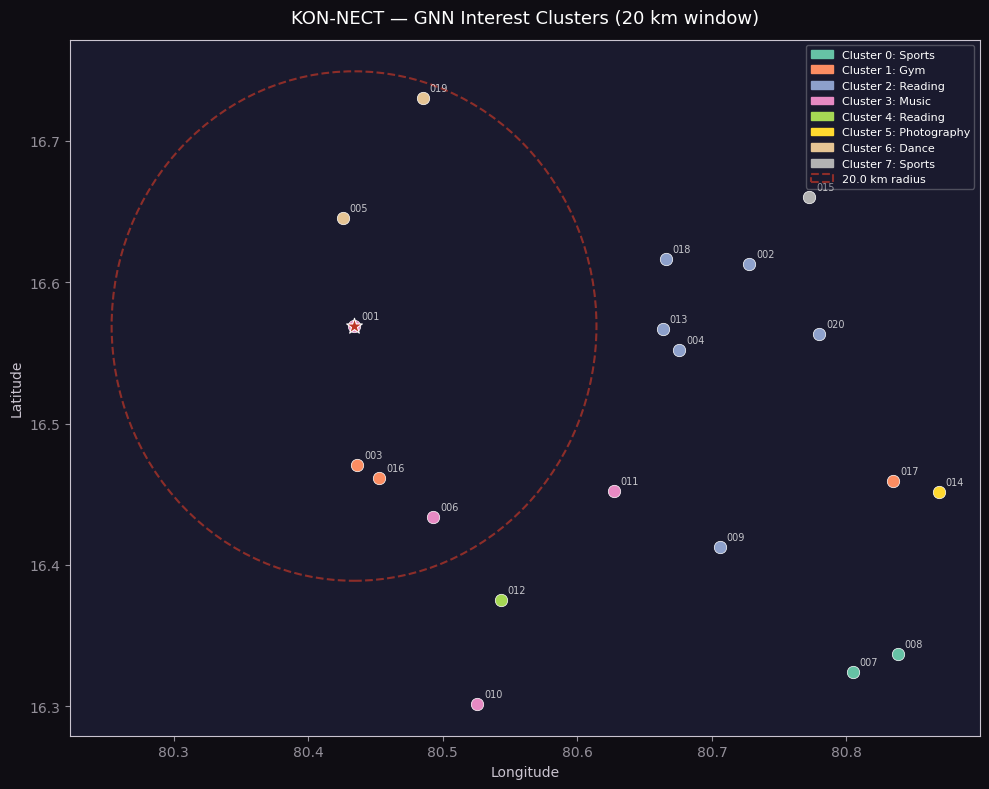

Cluster summary:
  Cluster 0 — Sports            : 2 users
Cluster summary:
  Cluster 1 — Gym               : 3 users
Cluster summary:
  Cluster 2 — Reading           : 6 users
Cluster summary:
  Cluster 3 — Music             : 4 users
Cluster summary:
  Cluster 4 — Reading           : 1 users
Cluster summary:
  Cluster 5 — Photography       : 1 users
Cluster summary:
  Cluster 6 — Dance             : 2 users
Cluster summary:
  Cluster 7 — Sports            : 1 users


<Figure size 640x480 with 0 Axes>

In [11]:
COLORS = plt.cm.Set2.colors  # colorblind-friendly palette

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#0f0d13")

# Plot all users
for i, u in enumerate(users):
    cid   = cluster_ids[i]
    color = COLORS[cid % len(COLORS)]
    ax.scatter(u["lon"], u["lat"], c=[color], s=80, zorder=5, edgecolors="white", linewidths=0.5)
    ax.annotate(u["id"][-3:], (u["lon"], u["lat"]),
                textcoords="offset points", xytext=(5, 5),
                fontsize=7, color="white", alpha=0.75)

# 20 km radius circle around query user (approximate in degrees)
q_lat, q_lon = query["lat"], query["lon"]
radius_deg   = RADIUS_KM / 111.0
circle = plt.Circle((q_lon, q_lat), radius_deg,
                     fill=False, color="#be3627", linewidth=1.5,
                     linestyle="--", alpha=0.7, label=f"{RADIUS_KM} km radius")
ax.add_patch(circle)
ax.scatter(q_lon, q_lat, c="#be3627", s=140, zorder=10, marker="*",
           edgecolors="white", linewidths=0.8, label="query user")

# Legend patches
patches = [mpatches.Patch(color=COLORS[cid % len(COLORS)],
                           label=f"Cluster {cid}: {cluster_labels[cid]}")
           for cid in range(n_clusters)]
ax.legend(handles=patches + [circle], loc="upper right",
          fontsize=8, framealpha=0.3, labelcolor="white", facecolor="#1a1a2e")

ax.set_title("KON-NECT — GNN Interest Clusters (20 km window)",
             color="white", fontsize=13, pad=12)
ax.set_xlabel("Longitude", color="#CAC4D0")
ax.set_ylabel("Latitude",  color="#CAC4D0")
ax.tick_params(colors="#938F99")
for spine in ax.spines.values():
    spine.set_edgecolor("#CAC4D0")

plt.tight_layout()
plt.show()


# persist the figure and summarise cluster counts like the demographic notebook    count = sum(1 for c in cluster_ids if c == cid)

plt.savefig("gnn_clusters.png", dpi=150, bbox_inches="tight")
for cid, label in cluster_labels.items():
    print("Cluster summary:")
    count = sum(1 for i in range(N_USERS) if cluster_ids[i] == cid)
    print(f"  Cluster {cid} — {label:18s}: {count} users")

## 12. Full Pipeline — End-to-End Demo

This cell runs the complete pipeline for a single query user, exactly as the app would:

1. Filter to users within 20 km
2. Score each by Jaccard similarity  
3. Fetch road distance to the top match  
4. Produce GNN embeddings for the neighbourhood  
5. Cluster and report

In [12]:
def run_pipeline(query_user: dict, all_users: list):
    print("=" * 60)
    print(f"  QUERY USER : {query_user['id']}")
    print(f"  INTERESTS  : {', '.join(query_user['interests'])}")
    print(f"  LOCATION   : ({query_user['lat']}, {query_user['lon']})")
    print("=" * 60)

    nearby = get_nearby_users(query_user, all_users)
    print(f"\n[1] Nearby users within {RADIUS_KM} km : {len(nearby)}")

    if not nearby:
        print("  No users in range.")
        return

    ranked = rank_nearby_by_interest(query_user, nearby)
    print(f"\n[2] Jaccard similarity ranking (top 5):")
    print(f"  {'User':<13}{'Jaccard':<11}{'Shared interests'}")
    for u in ranked[:5]:
        shared_str = ", ".join(u["shared"]) if u["shared"] else "—"
        print(f"  {u['id']:<13}{u['jaccard']:<11}{shared_str}")

    best = ranked[0]
    road_km = get_road_distance_km(
        query_user["lat"], query_user["lon"],
        best["lat"],        best["lon"]
    )
    print(f"\n[3] Road distance to top match ({best['id']}) : {road_km:.2f} km")

    subgraph_users = [query_user] + nearby
    X_sub   = build_node_features(subgraph_users, INTERESTS_POOL)
    adj_sub = build_jaccard_matrix(subgraph_users) * build_geo_mask(subgraph_users)
    print(f"\n[4] GNN embedding for neighbourhood ({len(subgraph_users)} nodes) — shape: {X_sub.shape}")

    k = min(max(2, len(subgraph_users) // 3), len(subgraph_users))
    gnn_sub = KONNECTUserGNN(X_sub.shape[1], GNN_HIDDEN, GNN_EMBED_DIM)
    gnn_sub.eval()
    with torch.no_grad():
        emb_sub = gnn_sub(X_sub, adj_sub)

    emb_np2  = normalize(emb_sub.numpy(), norm="l2")
    km2      = KMeans(n_clusters=k, random_state=0, n_init="auto")
    cids     = km2.fit_predict(emb_np2)

    cluster_info = {}
    for i, cid in enumerate(cids):
        cluster_info.setdefault(cid, []).append(subgraph_users[i]["id"])

    print(f"\n[5] {k} Neighbourhood clusters:")
    for cid, members in cluster_info.items():
        print(f"  Cluster {cid}: {members}")

    print("\n" + "=" * 60)
    if ranked[0]["jaccard"] > 0 and road_km <= RADIUS_KM * 1.5:
        print("  RESULT : ✅  Match found — Reachable & Interest-Compatible")
    elif ranked[0]["jaccard"] == 0:
        print("  RESULT : ❌  No shared interests with any nearby user")
    else:
        print("  RESULT : ⚠️   Nearby users exist but road is long")
    print("=" * 60)


# Run for user_001
run_pipeline(users[0], users)

  QUERY USER : user_001
  INTERESTS  : Gym, Dance, Gaming
  LOCATION   : (16.569, 80.434)

[1] Nearby users within 20.0 km : 5

[2] Jaccard similarity ranking (top 5):
  User         Jaccard    Shared interests
  user_019     0.4        Gaming, Dance
  user_003     0.25       Gym
  user_005     0.25       Dance
  user_006     0.2        Dance
  user_016     0.2        Gym

[3] Road distance to top match (user_019) : 71.75 km

[4] GNN embedding for neighbourhood (6 nodes) — shape: torch.Size([6, 14])

[5] 2 Neighbourhood clusters:
  Cluster 0: ['user_001', 'user_005', 'user_006', 'user_019']
  Cluster 1: ['user_003', 'user_016']

  RESULT : ⚠️   Nearby users exist but road is long


## 13. Upgrade Path — From Current App to This Model

When the backend is upgraded to a GPU-capable server, this pipeline replaces the following Node.js code:

| Current (Node.js / MongoDB) | This model | File reference |
|---|---|---|
| `$geoNear maxDistance: 20000` | `get_nearby_users(radius_km=20)` | `server/index.js` |
| `sharedInterests.filter(...)` count sort | `jaccard_similarity + rank_nearby_by_interest` | `server/index.js — /api/users/nearby` |
| K-Means on `[lon, lat]` | `KONNECTUserGNN → KMeans on embeddings` | `client/src/components/Map.jsx — handleShowClusters` |
| OSRM fetch in `Map.jsx` | `get_road_distance_km` | `client/src/components/Map.jsx` |

### Recommended serving stack
- **Training**: Offline nightly on the full user graph  
- **Inference**: FastAPI microservice exposes `/embed` and `/rank` endpoints  
- **Storage**: Pre-computed embeddings stored in MongoDB alongside each user document and refreshed on interest updates  
- **Approximate NN search**: `faiss` or `hnswlib` for sub-millisecond ranked retrieval at scale

---
*© 2026 KON-NECT. Reference implementation — not yet in production.*